# 1. Configuração Inicial e Carregamento dos Dados


In [26]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline
CSV_PATH = '../data/raw/heart.csv'
# Carregar os dados
df = pd.read_csv(CSV_PATH)  # Ou conectar com seu banco SQL

# 2. Análise Inicial da Estrutura dos Dados


In [27]:
# Visualização rápida
print("=== PRIMEIRAS LINHAS ===")
print(df.head())

print("\n=== INFORMAÇÕES GERAIS ===")
print(df.info())

print("\n=== FORMA DO DATASET ===")
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df.describe())

print("\n=== TIPOS DE DADOS ===")
print(df.dtypes)

=== PRIMEIRAS LINHAS ===
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-nu

# 3. Análise de Valores Ausentes (Missing Values)


=== VALORES AUSENTES ===
Empty DataFrame
Columns: [Coluna, Valores Ausentes, Percentual (%)]
Index: []


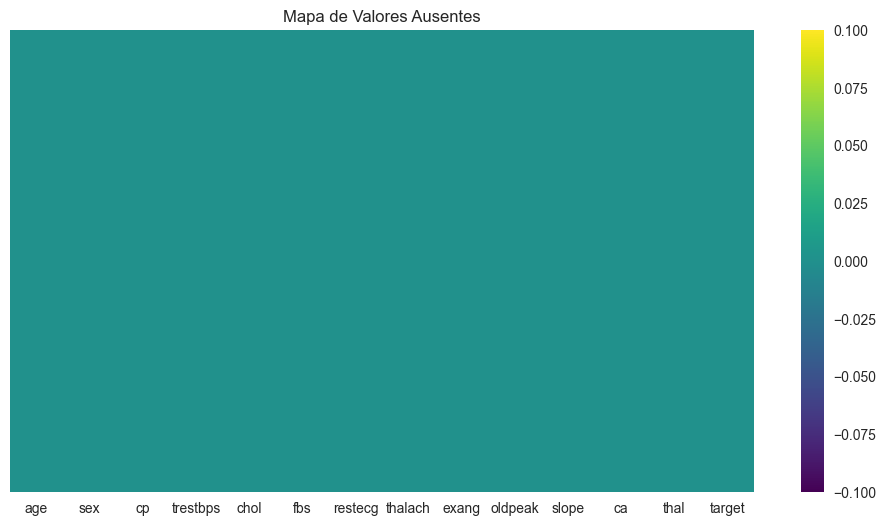

In [28]:
# Verificar valores ausentes
print("=== VALORES AUSENTES ===")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Coluna': df.columns,
    'Valores Ausentes': missing_data,
    'Percentual (%)': missing_percent
})
print(missing_df[missing_df['Valores Ausentes'] > 0])

# Visualizar missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Ausentes')
plt.show()

O arquivo CSV está completo, sem valores ausentes detectados pelo pandas.

# 4. Análise da Variável Target (Alvo)


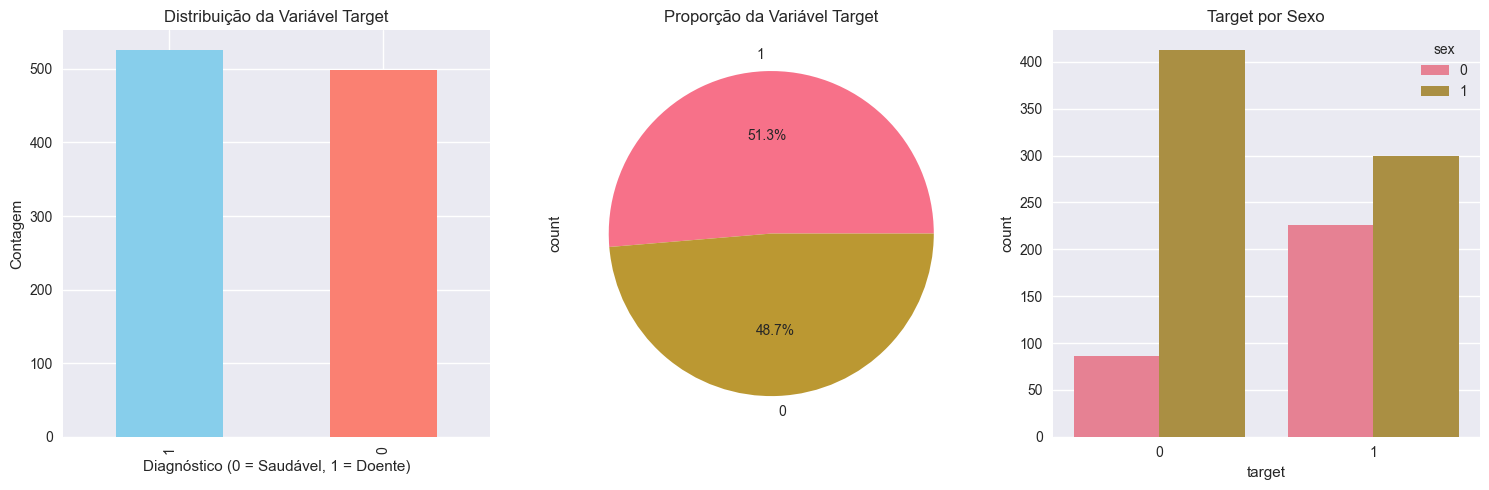

=== BALANCEAMENTO DA TARGET ===
target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [29]:
# Distribuição da variável target
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribuição da Variável Target')
plt.xlabel('Diagnóstico (0 = Saudável, 1 = Doente)')
plt.ylabel('Contagem')

plt.subplot(1, 3, 2)
df['target'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporção da Variável Target')

plt.subplot(1, 3, 3)
sns.countplot(x='target', data=df, hue='sex')  # Se tiver coluna de sexo
plt.title('Target por Sexo')

plt.tight_layout()
plt.show()

print("=== BALANCEAMENTO DA TARGET ===")
print(df['target'].value_counts(normalize=True))

# 5. Análise de Variáveis Numéricas


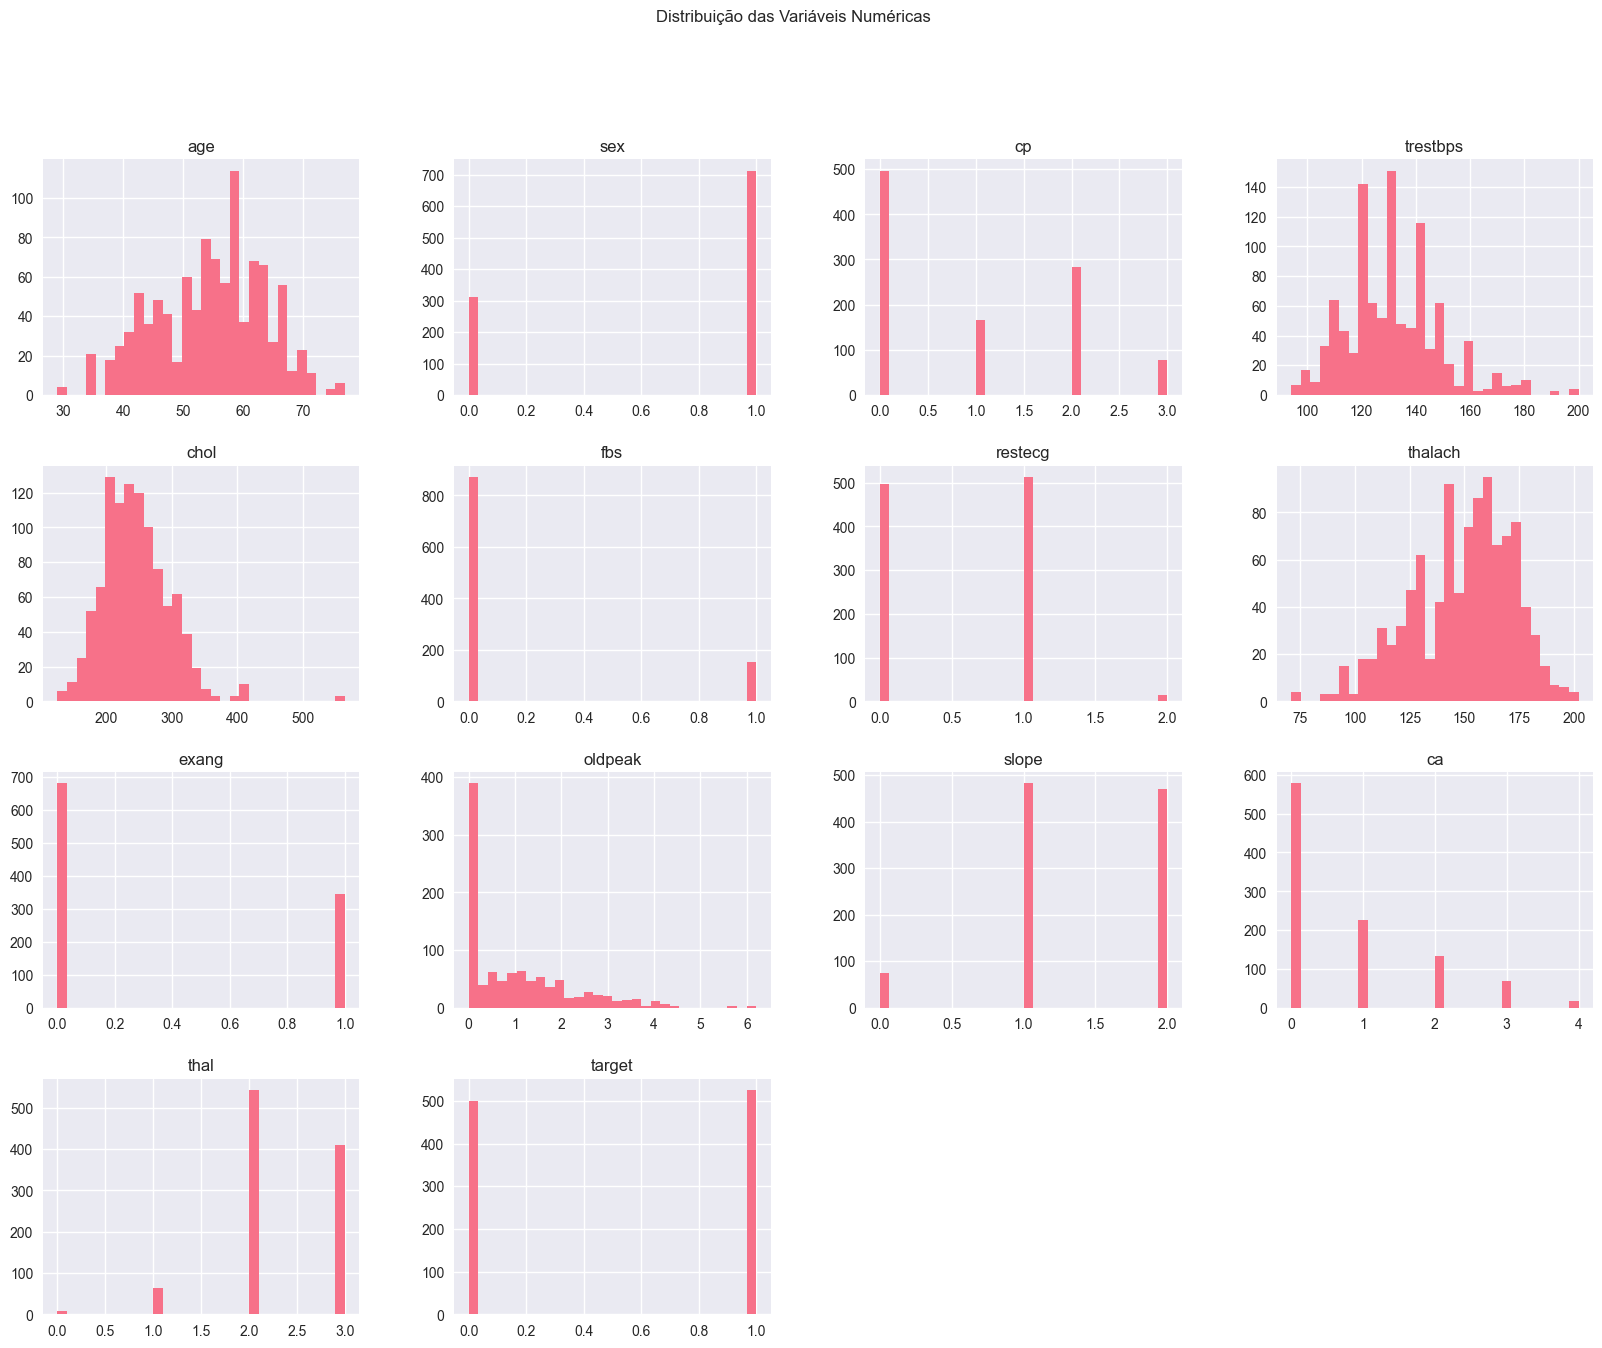

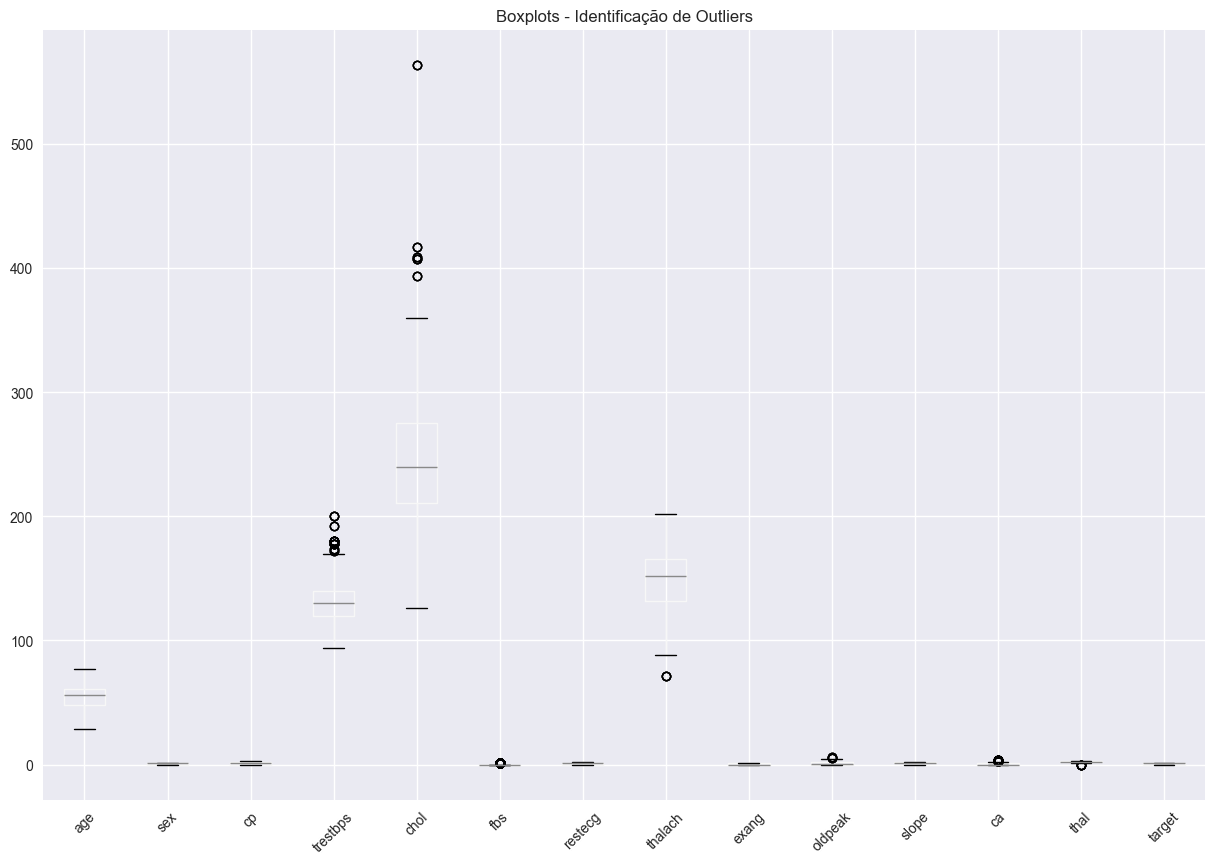

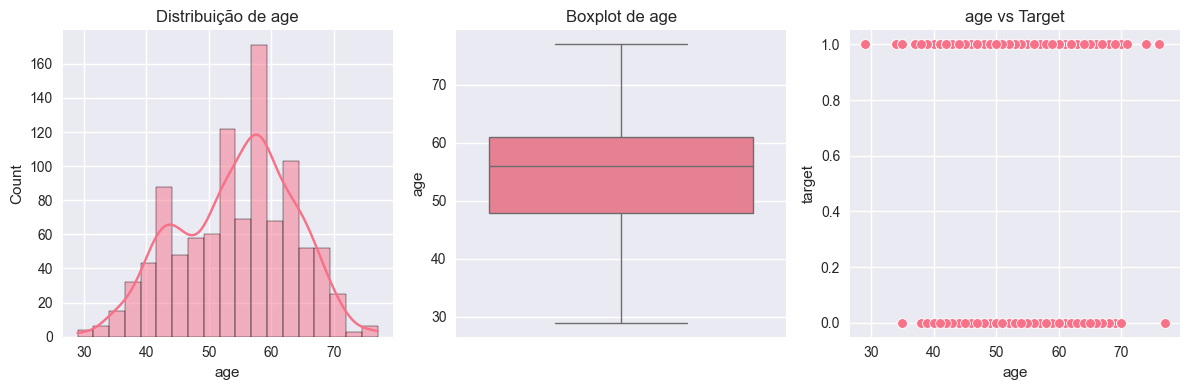


=== ANÁLISE DE AGE ===
Média: 54.43
Mediana: 56.00
Desvio Padrão: 9.07
Skewness: -0.25


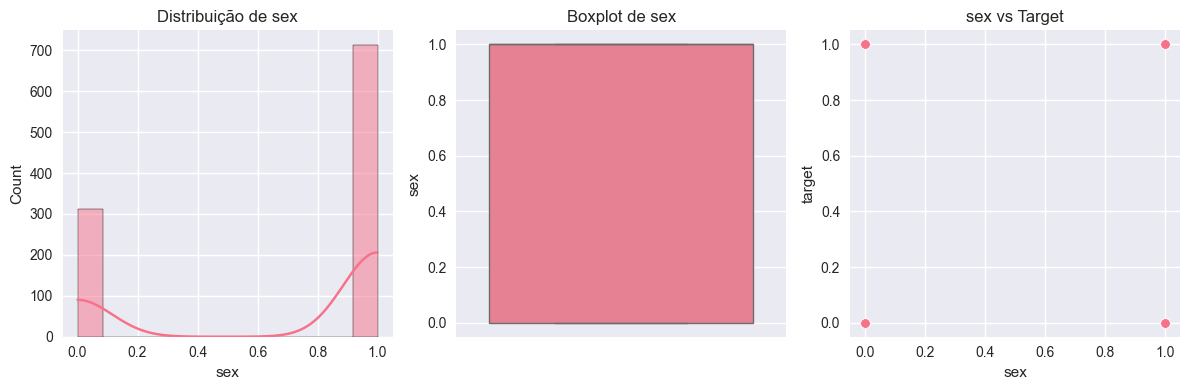


=== ANÁLISE DE SEX ===
Média: 0.70
Mediana: 1.00
Desvio Padrão: 0.46
Skewness: -0.85


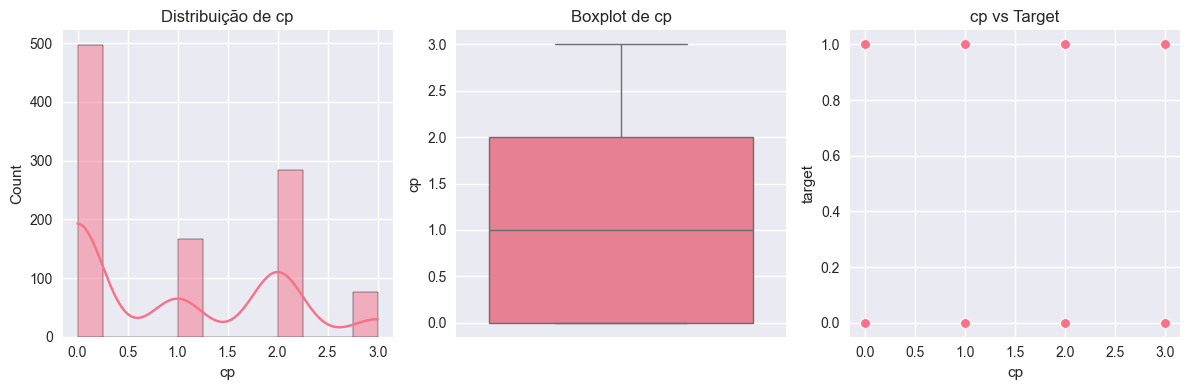


=== ANÁLISE DE CP ===
Média: 0.94
Mediana: 1.00
Desvio Padrão: 1.03
Skewness: 0.53


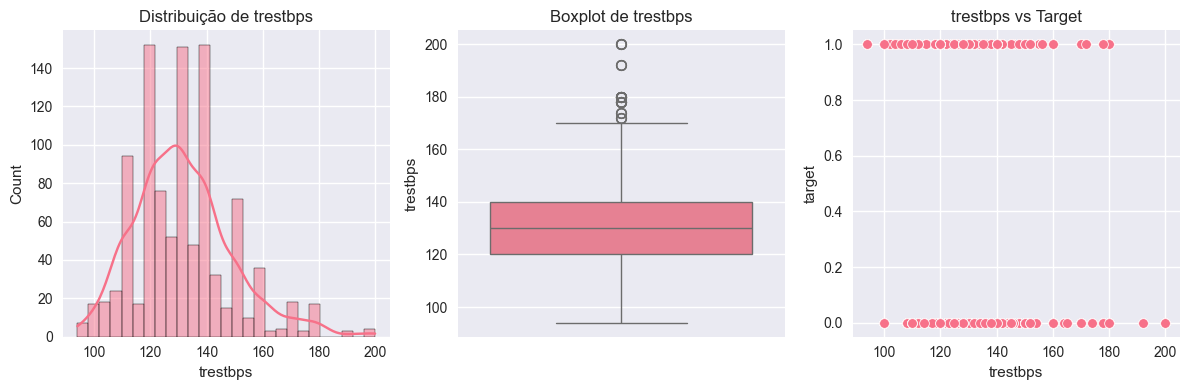


=== ANÁLISE DE TRESTBPS ===
Média: 131.61
Mediana: 130.00
Desvio Padrão: 17.52
Skewness: 0.74


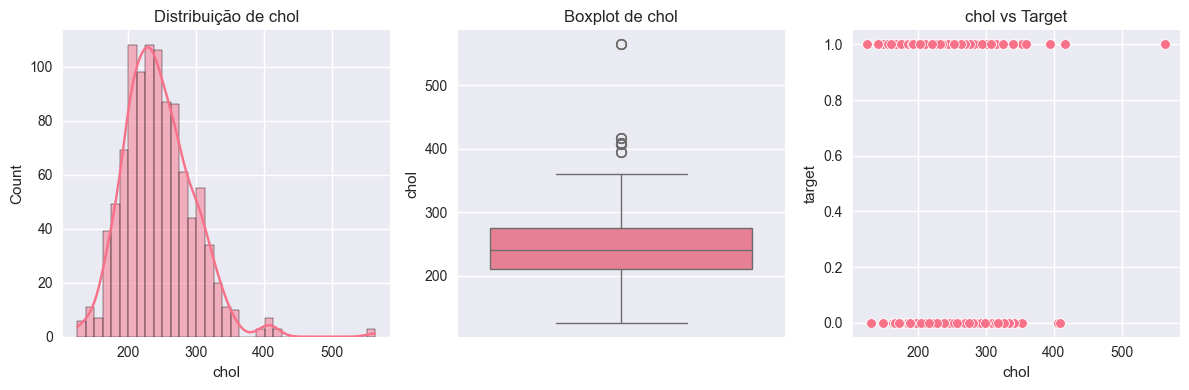


=== ANÁLISE DE CHOL ===
Média: 246.00
Mediana: 240.00
Desvio Padrão: 51.59
Skewness: 1.07


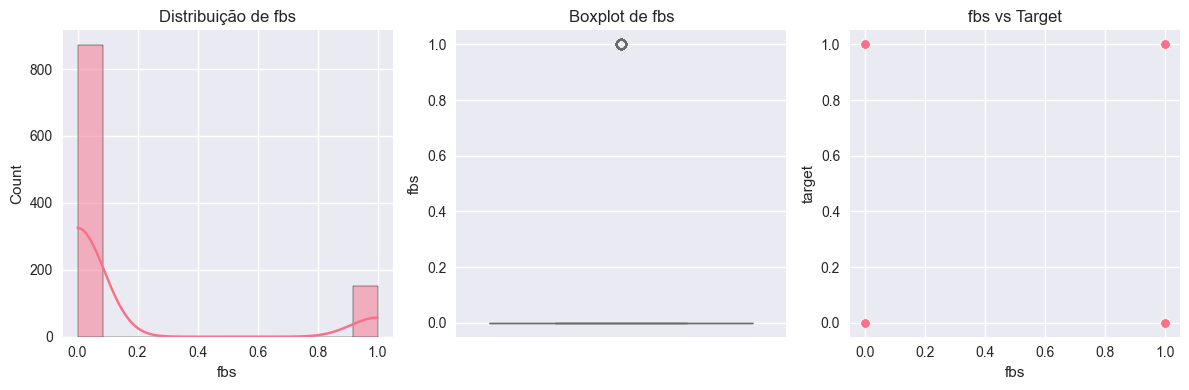


=== ANÁLISE DE FBS ===
Média: 0.15
Mediana: 0.00
Desvio Padrão: 0.36
Skewness: 1.97


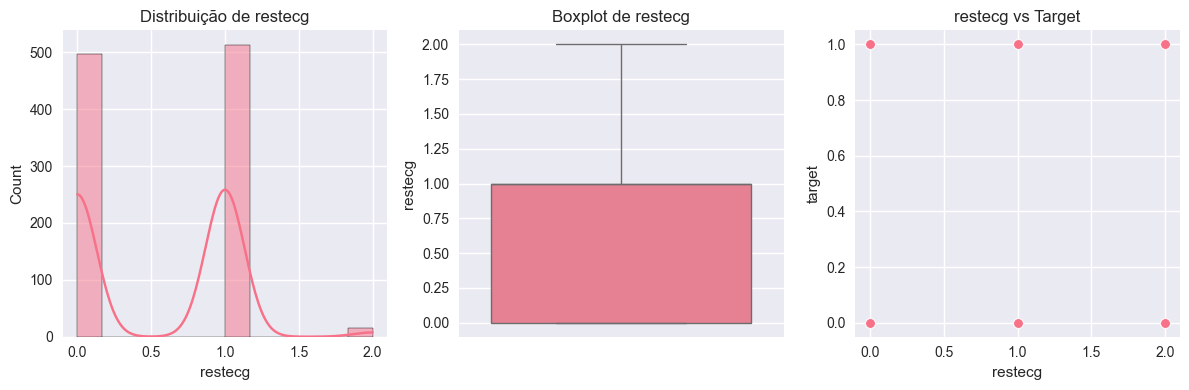


=== ANÁLISE DE RESTECG ===
Média: 0.53
Mediana: 1.00
Desvio Padrão: 0.53
Skewness: 0.18


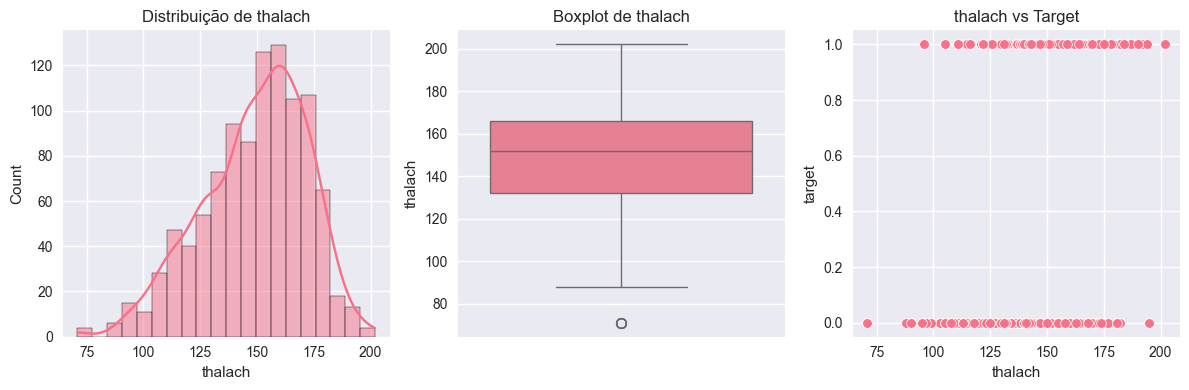


=== ANÁLISE DE THALACH ===
Média: 149.11
Mediana: 152.00
Desvio Padrão: 23.01
Skewness: -0.51


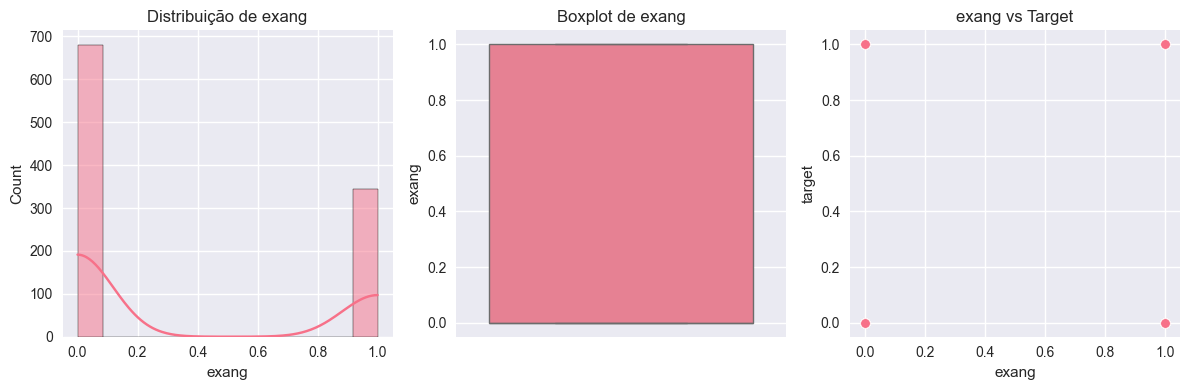


=== ANÁLISE DE EXANG ===
Média: 0.34
Mediana: 0.00
Desvio Padrão: 0.47
Skewness: 0.69


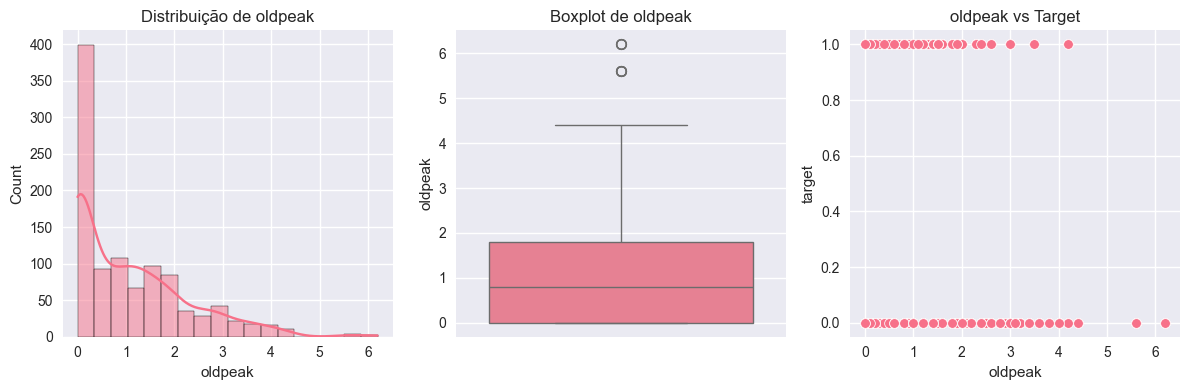


=== ANÁLISE DE OLDPEAK ===
Média: 1.07
Mediana: 0.80
Desvio Padrão: 1.18
Skewness: 1.21


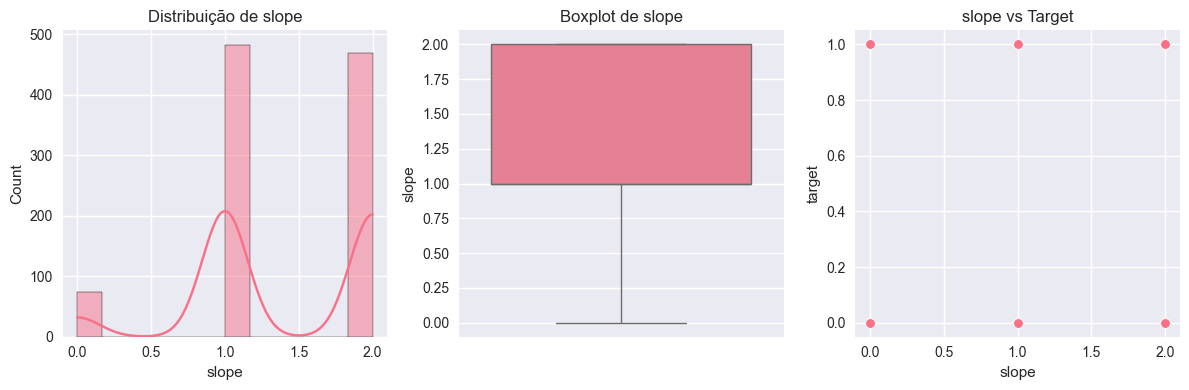


=== ANÁLISE DE SLOPE ===
Média: 1.39
Mediana: 1.00
Desvio Padrão: 0.62
Skewness: -0.48


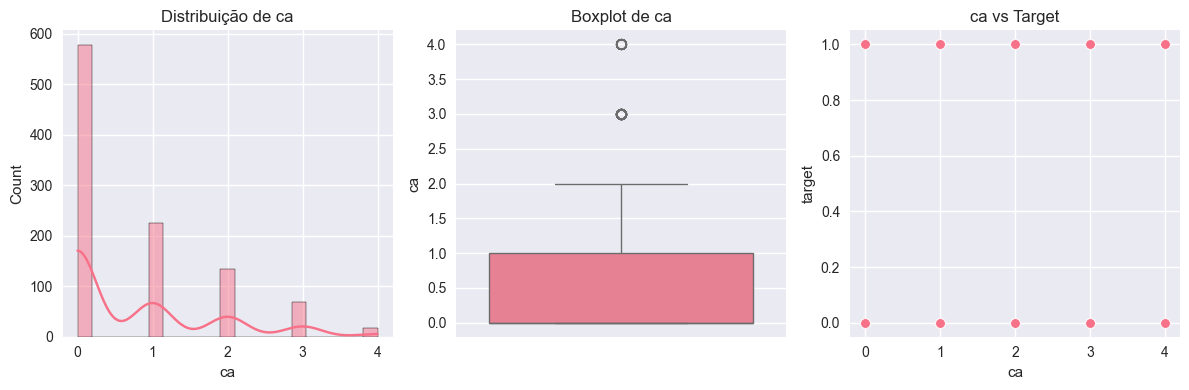


=== ANÁLISE DE CA ===
Média: 0.75
Mediana: 0.00
Desvio Padrão: 1.03
Skewness: 1.26


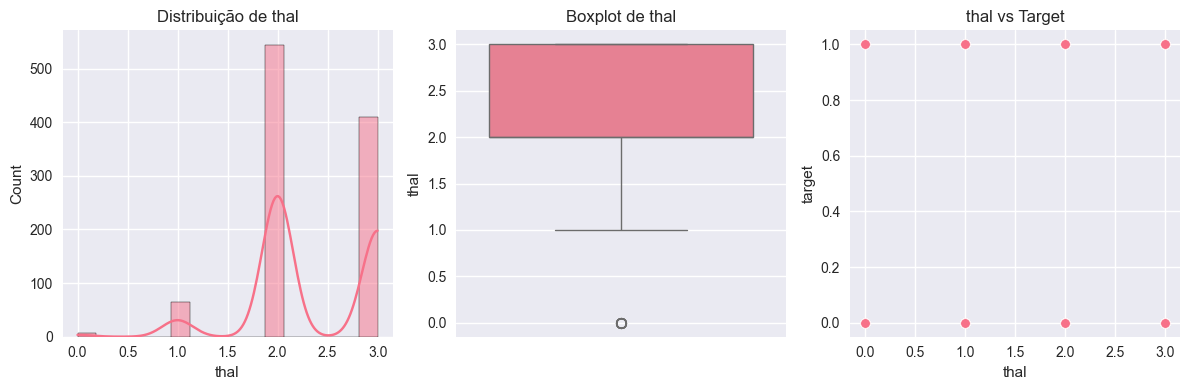


=== ANÁLISE DE THAL ===
Média: 2.32
Mediana: 2.00
Desvio Padrão: 0.62
Skewness: -0.52


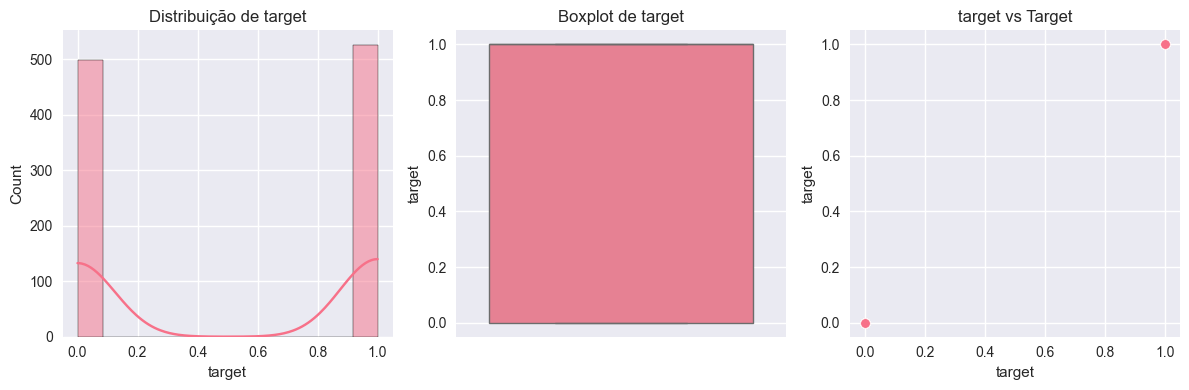


=== ANÁLISE DE TARGET ===
Média: 0.51
Mediana: 1.00
Desvio Padrão: 0.50
Skewness: -0.05


In [30]:
# Selecionar colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Histogramas para todas as variáveis numéricas
df[numeric_cols].hist(bins=30, figsize=(20, 15))
plt.suptitle('Distribuição das Variáveis Numéricas')
plt.show()

# Boxplots para identificar outliers
plt.figure(figsize=(15, 10))
df[numeric_cols].boxplot()
plt.title('Boxplots - Identificação de Outliers')
plt.xticks(rotation=45)
plt.show()

# Análise detalhada de cada variável numérica
for col in numeric_cols:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    
    plt.subplot(1, 3, 3)
    sns.scatterplot(x=col, y='target', data=df)
    plt.title(f'{col} vs Target')
    
    plt.tight_layout()
    plt.show()
    
    # Estatísticas
    print(f"\n=== ANÁLISE DE {col.upper()} ===")
    print(f"Média: {df[col].mean():.2f}")
    print(f"Mediana: {df[col].median():.2f}")
    print(f"Desvio Padrão: {df[col].std():.2f}")
    print(f"Skewness: {df[col].skew():.2f}")

# 6. Análise de Variáveis Categóricas


> **Nota:** Esta análise só será executada se existirem variáveis categóricas (do tipo texto ou categoria) no dataset. Caso todas as colunas sejam numéricas, esta célula será dispensável e não exibirá resultados.

In [31]:
# Selecionar colunas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribuição de {col}')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 3, 2)
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(f'Proporção de {col}')
    
    plt.subplot(1, 3, 3)
    pd.crosstab(df[col], df['target']).plot(kind='bar')
    plt.title(f'{col} vs Target')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n=== TABELA CRUZADA {col} x TARGET ===")
    print(pd.crosstab(df[col], df['target'], normalize='index'))

# 7. Análise de Correlação


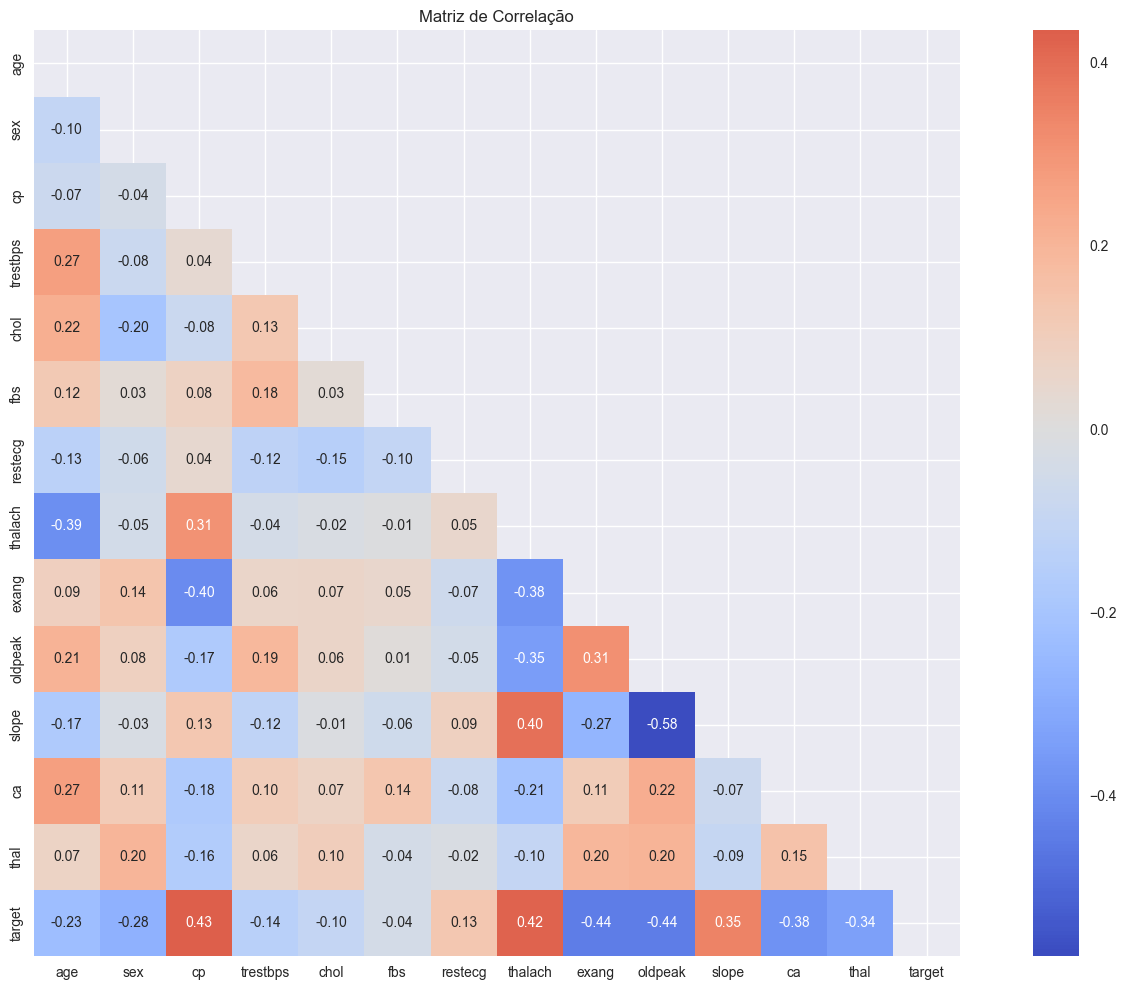

=== CORRELAÇÃO COM A TARGET ===
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


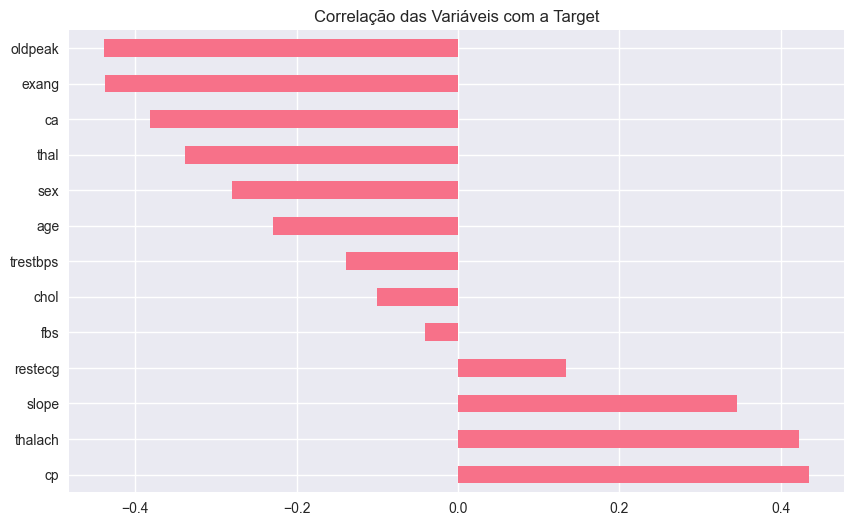

In [32]:
# Matriz de correlação
plt.figure(figsize=(15, 10))
correlation_matrix = df.corr(numeric_only=True)

# Heatmap de correlação
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

# Correlação com a target
target_corr = correlation_matrix['target'].sort_values(ascending=False)
print("=== CORRELAÇÃO COM A TARGET ===")
print(target_corr)

# Gráfico de correlação com a target
plt.figure(figsize=(10, 6))
target_corr.drop('target').plot(kind='barh')
plt.title('Correlação das Variáveis com a Target')
plt.show()

# 8. Análise de Outliers


In [33]:
# Identificar outliers usando IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Aplicar para cada variável numérica
for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\n=== OUTLIERS EM {col} ===")
    print(f"Limites: [{lower:.2f}, {upper:.2f}]")
    print(f"Número de outliers: {len(outliers)}")
    print(f"Percentual: {(len(outliers)/len(df))*100:.2f}%")


=== OUTLIERS EM age ===
Limites: [28.50, 80.50]
Número de outliers: 0
Percentual: 0.00%

=== OUTLIERS EM sex ===
Limites: [-1.50, 2.50]
Número de outliers: 0
Percentual: 0.00%

=== OUTLIERS EM cp ===
Limites: [-3.00, 5.00]
Número de outliers: 0
Percentual: 0.00%

=== OUTLIERS EM trestbps ===
Limites: [90.00, 170.00]
Número de outliers: 30
Percentual: 2.93%

=== OUTLIERS EM chol ===
Limites: [115.00, 371.00]
Número de outliers: 16
Percentual: 1.56%

=== OUTLIERS EM fbs ===
Limites: [0.00, 0.00]
Número de outliers: 153
Percentual: 14.93%

=== OUTLIERS EM restecg ===
Limites: [-1.50, 2.50]
Número de outliers: 0
Percentual: 0.00%

=== OUTLIERS EM thalach ===
Limites: [81.00, 217.00]
Número de outliers: 4
Percentual: 0.39%

=== OUTLIERS EM exang ===
Limites: [-1.50, 2.50]
Número de outliers: 0
Percentual: 0.00%

=== OUTLIERS EM oldpeak ===
Limites: [-2.70, 4.50]
Número de outliers: 7
Percentual: 0.68%

=== OUTLIERS EM slope ===
Limites: [-0.50, 3.50]
Número de outliers: 0
Percentual: 0.00%

# 9. Análise Multivariada


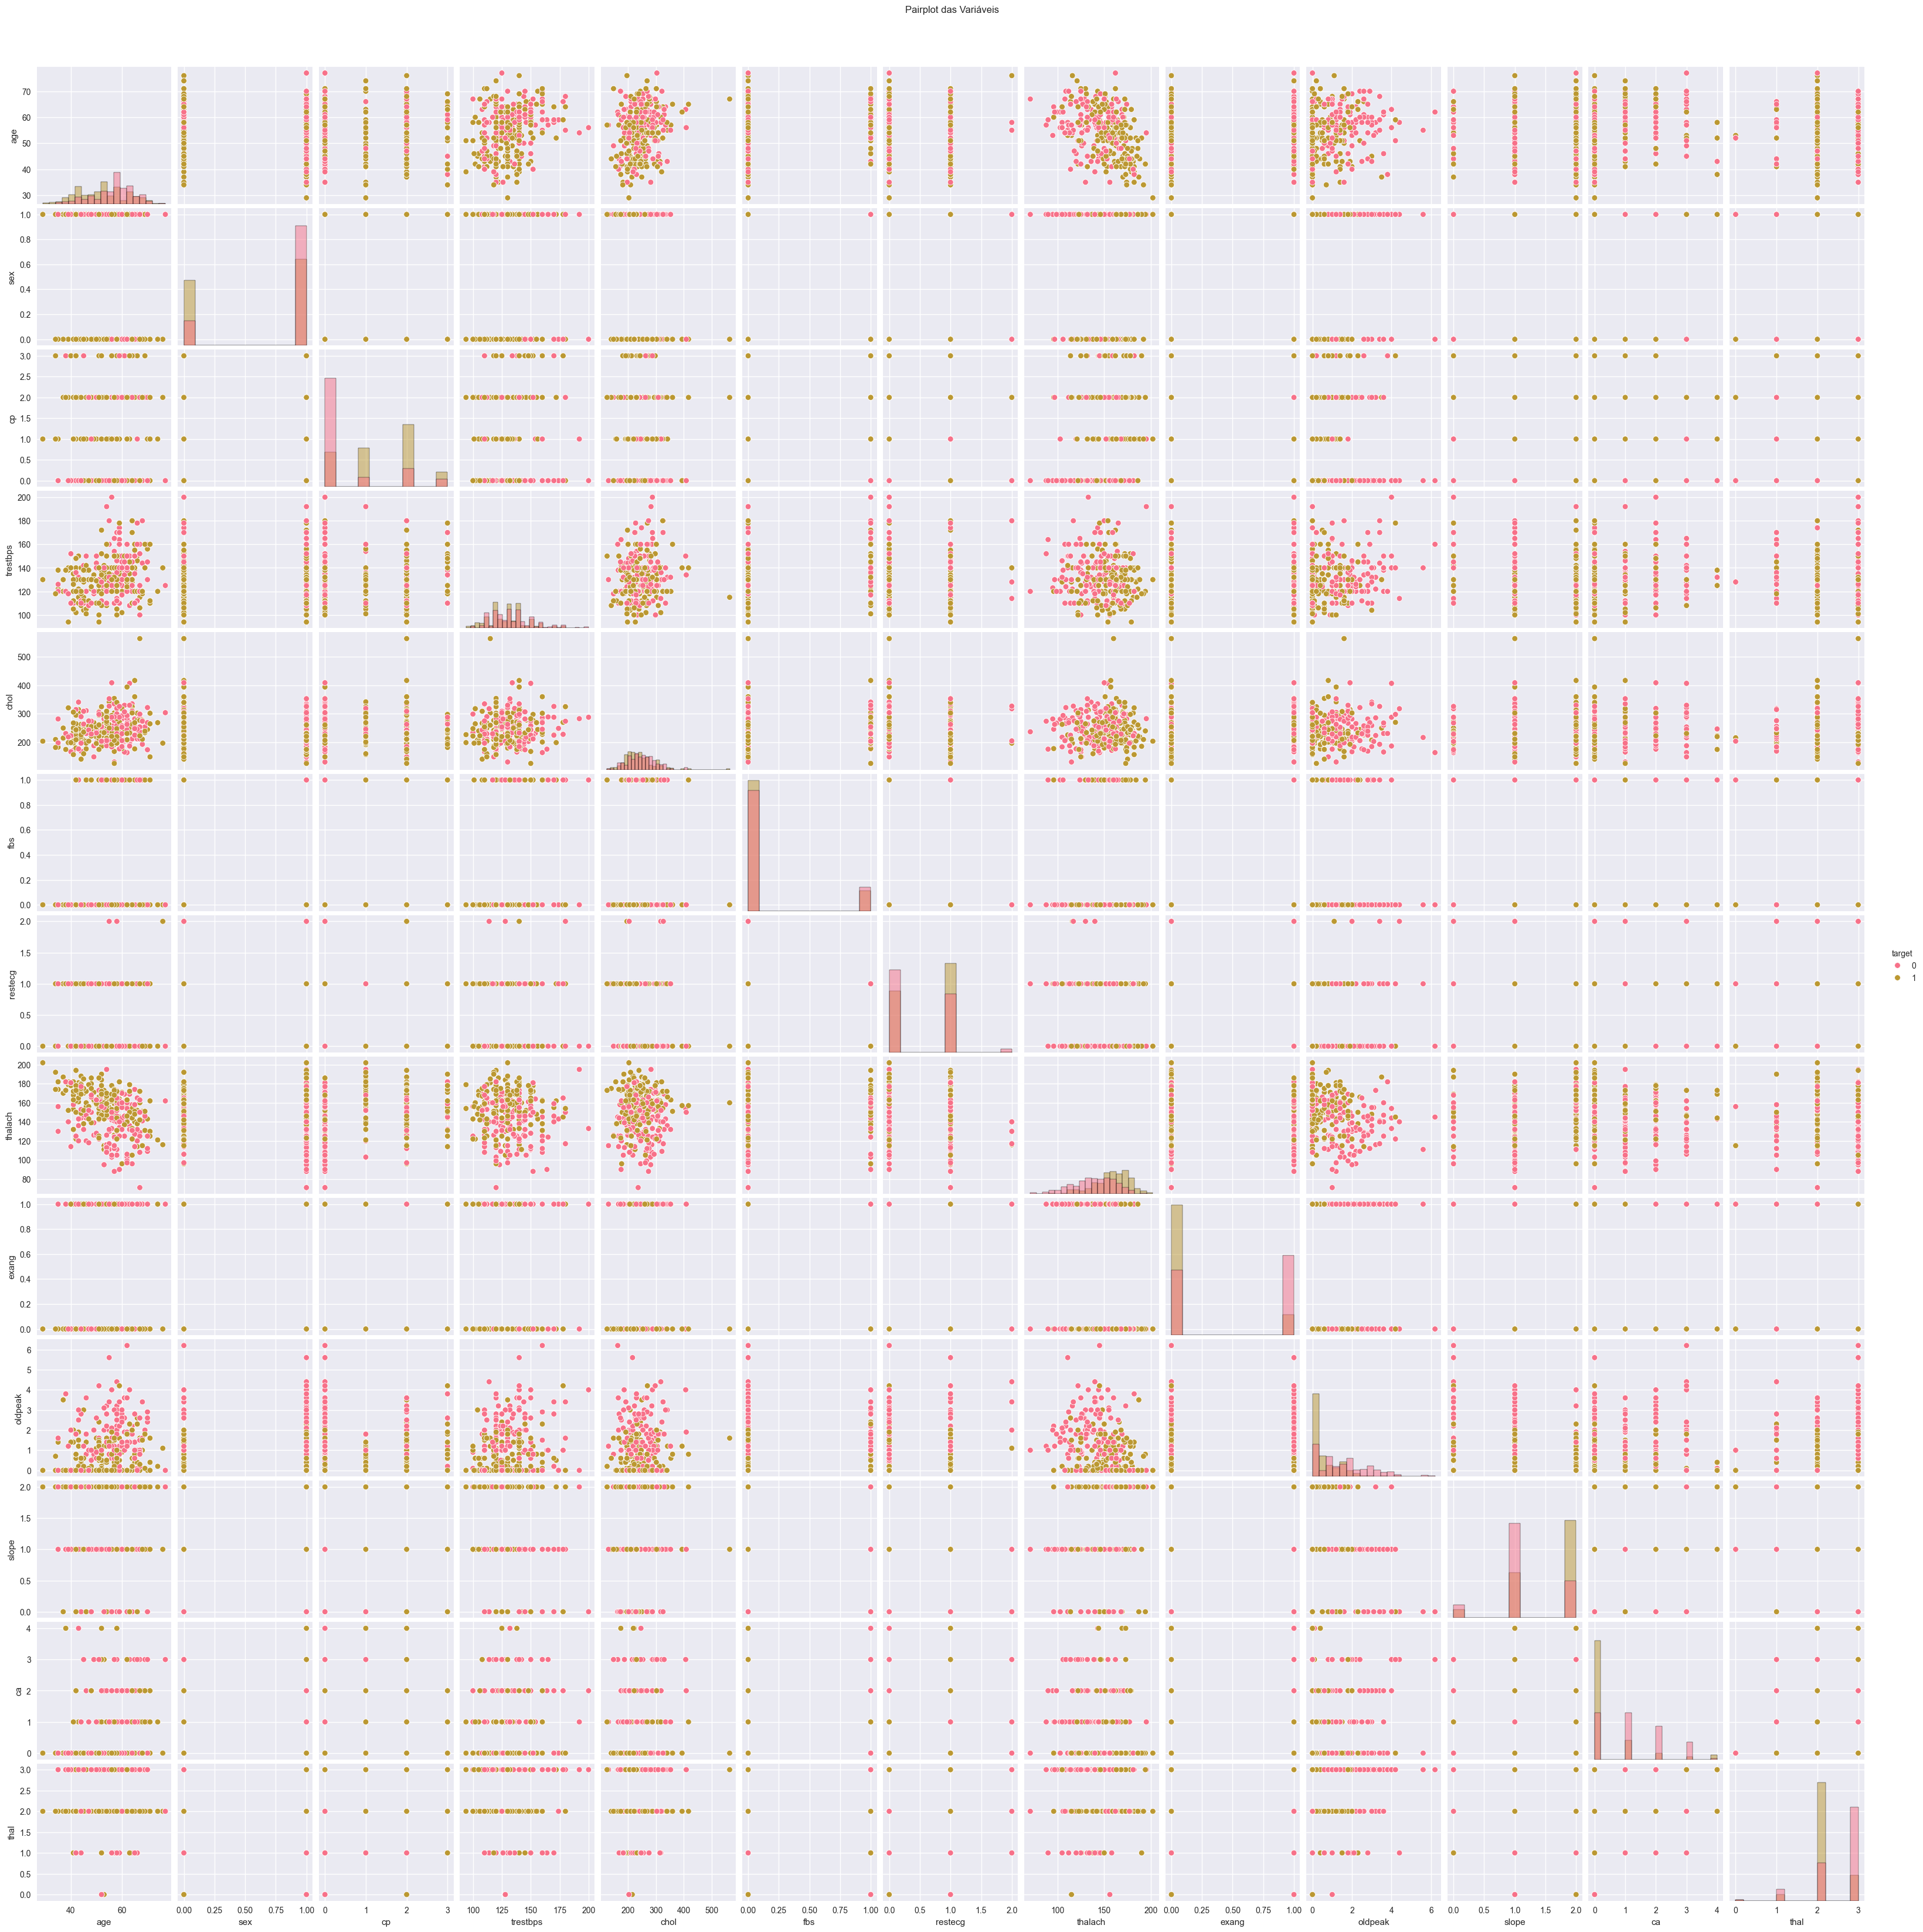

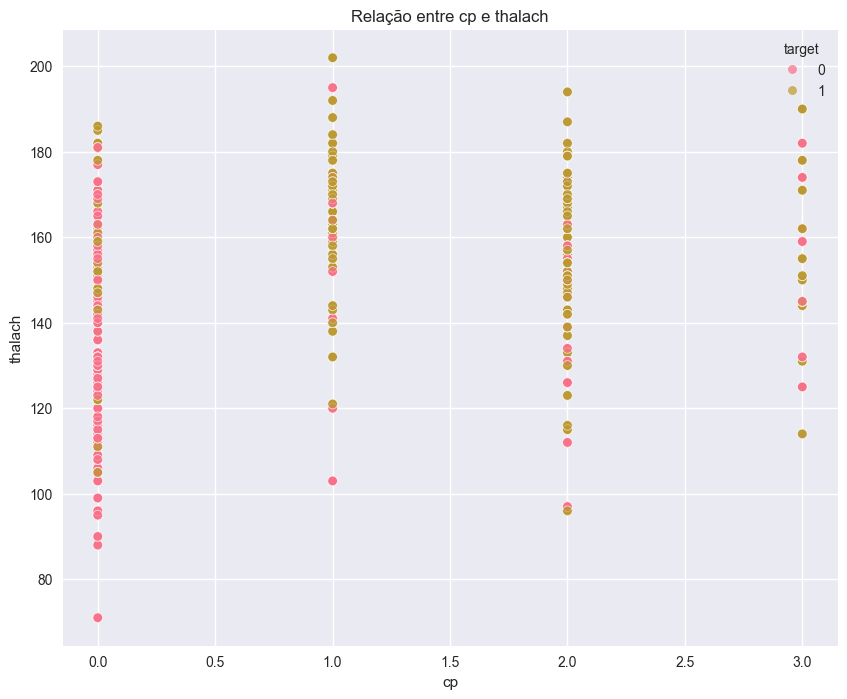

In [34]:
# Pairplot (pode ser pesado para muitos dados - use amostra se necessário)
sample_df = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample_df, hue='target', diag_kind='hist')
plt.suptitle('Pairplot das Variáveis', y=1.02)
plt.show()

# Scatter plots das variáveis mais correlacionadas
top_correlated = target_corr.index[1:4]  # Pega as 3 mais correlacionadas

if len(top_correlated) >= 2:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=top_correlated[0], 
                   y=top_correlated[1], 
                   hue='target', 
                   data=df, 
                   alpha=0.7)
    plt.title(f'Relação entre {top_correlated[0]} e {top_correlated[1]}')
    plt.show()

# 10. Análise de Duplicatas

=== VALORES DUPLICADOS ===
Número de linhas duplicadas: 723
Percentual de duplicatas: 70.54%

=== AMOSTRA DE LINHAS DUPLICADAS ===
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
60    29    1   1       130   204    0        0      202      0      0.0   
64    29    1   1       130   204    0        0      202      0      0.0   
118   29    1   1       130   204    0        0      202      0      0.0   
668   29    1   1       130   204    0        0      202      0      0.0   
12    34    0   1       118   210    0        1      192      0      0.7   
15    34    0   1       118   210    0        1      192      0      0.7   
779   34    0   1       118   210    0        1      192      0      0.7   
143   34    1   3       118   182    0        0      174      0      0.0   
201   34    1   3       118   182    0        0      174      0      0.0   
572   34    1   3       118   182    0        0      174      0      0.0   

     slope  ca  thal  target  
6

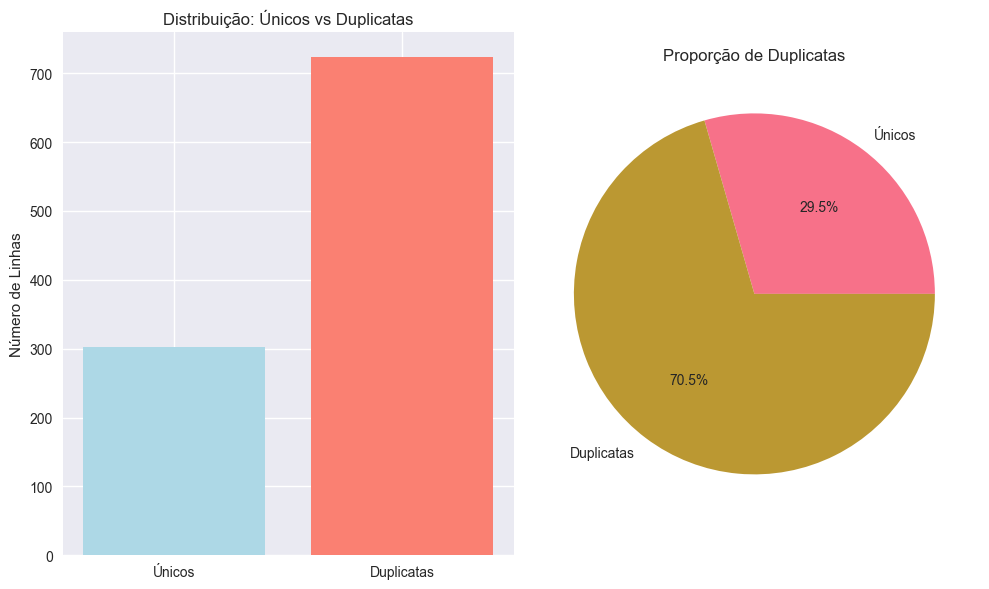

In [36]:
# Verificar linhas duplicadas
print("=== VALORES DUPLICADOS ===")
duplicadas = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicadas}")

if duplicadas > 0:
    print(f"Percentual de duplicatas: {(duplicadas/len(df))*100:.2f}%")
    
    # Mostrar amostra das linhas duplicadas
    print("\n=== AMOSTRA DE LINHAS DUPLICADAS ===")
    duplicatas_df = df[df.duplicated(keep=False)]  # keep=False marca todas as duplicatas
    print(duplicatas_df.sort_values(by=df.columns.tolist()).head(10))
    
    # Analisar padrões nas duplicatas
    print("\n=== ANÁLISE DAS DUPLICATAS ===")
    print("Contagem por grupo de duplicatas:")
    print(duplicatas_df.groupby(df.columns.tolist()).size().sort_values(ascending=False).head())
    
    # Verificar se as duplicatas estão balanceadas na target
    if 'target' in df.columns:
        print("\n=== DISTRIBUIÇÃO DA TARGET NAS DUPLICATAS ===")
        print(duplicatas_df['target'].value_counts(normalize=True))
else:
    print("Não há linhas duplicadas no dataset.")
    # Definir duplicatas_df como DataFrame vazio para evitar erro
    duplicatas_df = pd.DataFrame(columns=df.columns)

# Gráfico para mostrar duplicatas vs únicos
plt.figure(figsize=(10, 6))

duplicatas_data = {
    'Únicos': len(df) - duplicadas,
    'Duplicatas': duplicadas
}

plt.subplot(1, 2, 1)
plt.bar(duplicatas_data.keys(), duplicatas_data.values(), color=['lightblue', 'salmon'])
plt.title('Distribuição: Únicos vs Duplicatas')
plt.ylabel('Número de Linhas')

plt.subplot(1, 2, 2)
plt.pie(duplicatas_data.values(), labels=duplicatas_data.keys(), autopct='%1.1f%%')
plt.title('Proporção de Duplicatas')

plt.tight_layout()
plt.show()

# 11. Resumo Executivo do EDA


In [39]:
# Criar um resumo automático
def generate_eda_summary(df):
    summary = {
        'total_linhas': len(df),
        'total_colunas': len(df.columns),
        'colunas_numericas': len(df.select_dtypes(include=[np.number]).columns),
        'colunas_categoricas': len(df.select_dtypes(include=['object']).columns),
        'valores_ausentes_total': df.isnull().sum().sum(),
        'percentual_ausentes': (df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100,
        'balanceamento_target': df['target'].value_counts(normalize=True).to_dict() if 'target' in df.columns else None,
        'linhas_duplicadas': df.duplicated().sum(),
        'percentual_duplicadas': (df.duplicated().sum() / len(df)) * 100 if len(df) > 0 else 0
    }
    return summary

eda_summary = generate_eda_summary(df)
print("=== RESUMO DO EDA ===")
for key, value in eda_summary.items():
    print(f"{key}: {value}")

=== RESUMO DO EDA ===
total_linhas: 1025
total_colunas: 14
colunas_numericas: 14
colunas_categoricas: 0
valores_ausentes_total: 0
percentual_ausentes: 0.0
balanceamento_target: {1: 0.5131707317073171, 0: 0.4868292682926829}
linhas_duplicadas: 723
percentual_duplicadas: 70.53658536585365


In [46]:
# Salvar o resumo do EDA em um arquivo txt estruturado na pasta 'reports' na raiz do projeto
import os

# Caminho relativo para a pasta 'reports' na raiz do projeto
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'reports'))
report_filename = 'eda_resumo.txt'
report_path = os.path.join(report_dir, report_filename)

# Cria a pasta se não existir
if not os.path.exists(report_dir):
    os.makedirs(report_dir)

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('=== RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA DE DADOS ===\n')
    f.write('-' * 60 + '\n')
    f.write('INFORMAÇÕES GERAIS:\n')
    f.write(f"Total de linhas: {eda_summary['total_linhas']}\n")
    f.write(f"Total de colunas: {eda_summary['total_colunas']}\n")
    f.write(f"Colunas numéricas: {eda_summary['colunas_numericas']}\n")
    f.write(f"Colunas categóricas: {eda_summary['colunas_categoricas']}\n")
    f.write('-' * 60 + '\n')
    f.write('VALORES AUSENTES:\n')
    f.write(f"Total de valores ausentes: {eda_summary['valores_ausentes_total']}\n")
    f.write(f"Percentual de ausentes: {eda_summary['percentual_ausentes']:.2f}%\n")
    f.write('-' * 60 + '\n')
    f.write('DUPLICATAS:\n')
    f.write(f"Linhas duplicadas: {eda_summary['linhas_duplicadas']}\n")
    f.write(f"Percentual de duplicadas: {eda_summary['percentual_duplicadas']:.2f}%\n")
    f.write('-' * 60 + '\n')
    if eda_summary['balanceamento_target'] is not None:
        f.write('BALANCEAMENTO DA VARIÁVEL TARGET:\n')
        for k, v in eda_summary['balanceamento_target'].items():
            f.write(f"Classe {k}: {v:.2%}\n")
        f.write('-' * 60 + '\n')
print(f"Resumo do EDA salvo em: {report_path}")


Resumo do EDA salvo em: c:\Users\gyova\OneDrive\Documentos\Projeto 1 - Monitoramento de Doenças\reports\eda_resumo.txt
